In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv("diabetes.csv")

In [ ]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
X = data.drop("Outcome",axis=1)
y = data["Outcome"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
log_reg.coef_

array([[ 0.06106262,  0.0337888 , -0.01387792,  0.00474554, -0.0019446 ,
         0.10151985,  0.59002294,  0.03768787]])

In [ ]:
y_pred_train = log_reg.predict(X_train)

In [ ]:
pd.DataFrame({'y_train':y_train,'y_pred_train':y_pred_train})

,y_train,y_pred_train
60,0,0
618,1,0
346,0,0
294,0,1
231,1,1
...,...,...
71,0,0
106,0,0
270,1,1
435,1,1


In [ ]:
correct = 0
for y,yp in zip(y_train,y_pred_train):
  if y == yp:
    correct += 1

correct

473

In [ ]:
correct/614*100

77.0358306188925

# Model Performance Evaluation

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

In [ ]:
confusion_matrix(y_train,y_pred_train)
'''
TP = Actual and predicted positive (1)
TN = Actual and predicted negative (0)
FP = Actual negative (0) and predicted positive (1)
FN = Actual positive (1) and predicted negative (0)
'''

array([[353,  48],
       [ 93, 120]])

In [ ]:
accuracy_score(y_train,y_pred_train)
# Formula: (TP + TN) / (TP + TN + FP + FN)

0.7703583061889251

In [ ]:
# How many positive predictions are correct
precision_score(y_train,y_pred_train)
# Formula: TP / (TP + FP)

0.7142857142857143

In [ ]:
#  How many actual positives are calssified correctly
recall_score(y_train,y_pred_train)
# Formula: TP / (TP + FN)

0.5633802816901409

In [ ]:
f1_score(y_train,y_pred_train)
# F1-Score= (2)(Precision)(Recall)/(Precision+Recall)

0.6299212598425197

In [ ]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       401
           1       0.71      0.56      0.63       213

    accuracy                           0.77       614
   macro avg       0.75      0.72      0.73       614
weighted avg       0.76      0.77      0.76       614



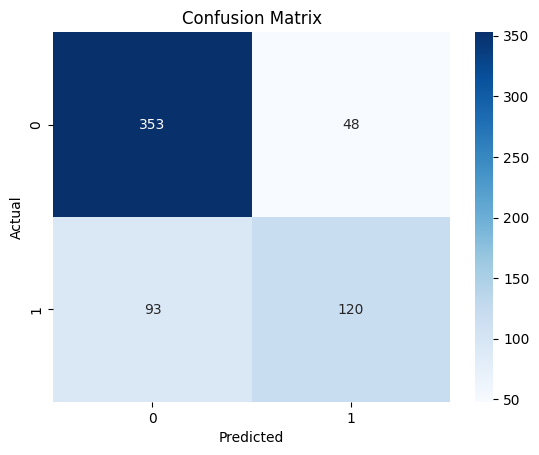

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_pred_train)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()